In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
from scipy.optimize import differential_evolution

In [2]:
df = pd.read_csv(r'xy_data.csv')

In [3]:
df

,x,y
0,88.364456,57.784378
1,74.283936,54.406780
2,60.256474,46.311462
3,82.134370,57.717567
4,101.036390,67.849340
...,...,...
1495,99.653260,68.500260
1496,66.533380,47.578316
1497,83.447020,57.533510
1498,63.372417,47.135735


In [4]:
df = df.rename(columns={df.columns[0]:"x", df.columns[1]:"y"})
df = df[["x","y"]].copy()
N = len(df)
xy = df.to_numpy()
t = np.linspace(6.0, 60.0, N)

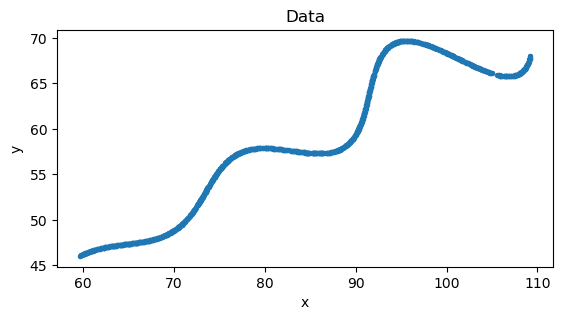

In [5]:
plt.figure()
plt.scatter(df['x'].to_numpy(), df['y'].to_numpy(), s=8)
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Data')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [6]:
def fxy(t, th, M, X):
    e = np.exp(M*np.abs(t))*np.sin(0.3*t)
    x = t*np.cos(th) - e*np.sin(th) + X
    y = 42 + t*np.sin(th) + e*np.cos(th)
    return x, y

In [7]:
def obj(p):
    th_deg, M, X = p
    th = np.deg2rad(th_deg)
    x, y = fxy(t, th, M, X)
    m = np.stack([x,y],1)
    return np.sum(np.abs(m-xy))

In [8]:
bounds = [(0.0,50.0),(-0.05,0.05),(0.0,100.0)]
res = differential_evolution(obj, bounds=bounds, maxiter=1000, tol=1e-7, polish=True, seed=42)
res

             message: Optimization terminated successfully.
             success: True
                 fun: 37865.09418979341
                   x: [ 2.812e+01  2.139e-02  5.490e+01]
                 nit: 30
                nfev: 1471
          population: [[ 2.812e+01  2.139e-02  5.490e+01]
                       [ 2.812e+01  2.134e-02  5.490e+01]
                       ...
                       [ 2.812e+01  2.139e-02  5.490e+01]
                       [ 2.812e+01  2.139e-02  5.490e+01]]
 population_energies: [ 3.787e+04  3.787e+04 ...  3.787e+04  3.787e+04]
                 jac: [ 1.804e-01  7.478e+01  0.000e+00]

In [9]:
th_deg, M, X = res.x
th = np.deg2rad(th_deg)
xm, ym = fxy(t, th, M, X)
L1 = np.sum(np.abs(np.stack([xm,ym],1)-xy))
print(f'theta_deg={th_deg:.6f}')
print(f'M={M:.6f}')
print(f'X={X:.6f}')
print(f'L1={L1:.6f}')

theta_deg=28.118109
M=0.021387
X=54.899655
L1=37865.094190


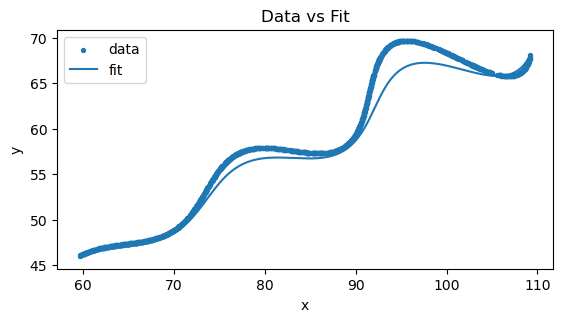

In [10]:
plt.figure()
plt.scatter(df['x'].to_numpy(), df['y'].to_numpy(), s=8, label='data')
plt.plot(xm, ym, label='fit')
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Data vs Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [11]:
latex = (r"\left(" +
         r"t\cos(" + f"{th:.6f}" + r")" +
         r"-e^{" + f"{M:.6f}" + r"\left|t\right|}\cdot\sin(0.3t)\sin(" + f"{th:.6f}" + r")" +
         r"+" + f"{X:.6f}" +
         r",\,42+t\sin(" + f"{th:.6f}" + r")" +
         r"+e^{" + f"{M:.6f}" + r"\left|t\right|}\cdot\sin(0.3t)\cos(" + f"{th:.6f}" + r")" +
         r"\right)")
print(latex)

\left(t\cos(0.490754)-e^{0.021387\left|t\right|}\cdot\sin(0.3t)\sin(0.490754)+54.899655,\,42+t\sin(0.490754)+e^{0.021387\left|t\right|}\cdot\sin(0.3t)\cos(0.490754)\right)


In [12]:
with open('RESULT_README.md','w',encoding='utf-8') as f:
    f.write('# Result\n')
    f.write(f'theta_deg: {th_deg:.6f}\n')
    f.write(f'M: {M:.6f}\n')
    f.write(f'X: {X:.6f}\n')
    f.write(f'L1: {L1:.6f}\n\n')
    f.write('LaTeX:\n\n')
    f.write(latex)
print('Saved RESULT_README.md')

Saved RESULT_README.md
